In [1]:
import os
import tensorflow as tf


2026-03-31 07:45:34.243551: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774943134.406646      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774943134.455996      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774943134.835675      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774943134.835703      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774943134.835706      55 computation_placer.cc:177] computation placer alr

In [2]:
# Verify GPU
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [37]:
import os

# Deep search to find Training folder
for root, dirs, files in os.walk('/kaggle/input'):
    for d in dirs:
        if d == 'Training':
            print("✅ FOUND Training at:", os.path.join(root, d))
        if d == 'Testing':
            print("✅ FOUND Testing at:", os.path.join(root, d))

✅ FOUND Training at: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
✅ FOUND Testing at: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing


In [114]:
import os

# ✅ Set dataset paths directly
TRAIN_DIR = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"
TEST_DIR = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"
TEST_DIR = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"

# ✅ Check classes
train_classes = sorted(os.listdir(TRAIN_DIR))
test_classes = sorted(os.listdir(TEST_DIR))

print("Training classes:", train_classes)
print("Testing classes:", test_classes)

# ✅ Count images per class
for cls in train_classes:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"{cls}: {n} images")

Training classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Testing classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images


In [105]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input 

from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [113]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
import json


IMG_SIZE = 300
BATCH_SIZE = 32
NUM_CLASSES = 4

# AUGMENTATION 
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,

    horizontal_flip=True,
    fill_mode="nearest",

    validation_split=0.15
)

test_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

test_gen = test_val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Train:", train_gen.samples)
print("Val:", val_gen.samples)
print("Test:", test_gen.samples)
print("Classes:", list(train_gen.class_indices.keys()))



Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Train: 4760
Val: 840
Test: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [115]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
import tensorflow as tf
import os

NUM_CLASSES = 4
MODEL_PATH = "/kaggle/working/brain_tumor_final.keras"

# BASE MODEL
base = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Phase 1 → Freeze base
base.trainable = False

# Clean head 
x = base.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(512, activation="relu")(x)
x = Dropout(0.4)(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)

out = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base.input, outputs=out)

# Better loss (reduced smoothing)
loss_fn = CategoricalCrossentropy(label_smoothing=0.05)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=["accuracy"]
)

print("Model ready for Phase 1")


Model ready for Phase 1


In [138]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os

MODEL_PATH = "/kaggle/working/brain_tumor_best.keras"
os.makedirs("/kaggle/working", exist_ok=True)

callbacks = [
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]



In [139]:
print("Phase 1: Training head only (base frozen)...")
print("Expected val_accuracy: 85–93% by epoch 8–10\n")

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12,
    callbacks=callbacks,
    verbose=1
)

p1_acc = max(history1.history['val_accuracy'])
print(f" Phase 1 Best Accuracy: {p1_acc*100:.2f}%")

# Save backup
model.save("/kaggle/working/phase1_model.keras")

# Safety check before Phase 2
if p1_acc < 0.80:
    print("\n WARNING: val_accuracy below 80% — DO NOT run Phase 2")
    print("Fix training first (data / preprocessing issue)")
else:
    print("\n Good! Proceed to Phase 2 (fine-tuning)")

Phase 1: Training head only (base frozen)...
Expected val_accuracy: 85–93% by epoch 8–10

Epoch 1/12
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.5315 - loss: 1.2577
Epoch 1: val_accuracy improved from -inf to 0.83929, saving model to /kaggle/working/brain_tumor_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.5323 - loss: 1.2557 - val_accuracy: 0.8393 - val_loss: 0.6430 - learning_rate: 1.0000e-04
Epoch 2/12
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.7981 - loss: 0.6634
Epoch 2: val_accuracy improved from 0.83929 to 0.87024, saving model to /kaggle/working/brain_tumor_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 110s 738ms/step - accuracy: 0.7982 - loss: 0.6633 - val_accuracy: 0.8702 - val_loss: 0.4950 - learning_rate: 1.0000e-04
Epoch 3/12
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.8264 - loss: 0.6049
Epoch 3: val_accuracy improved from 0.87024 to 0.89762, saving model to /kaggle/working/brain_tumor_best.keras
149/149 ━━━━━━━━━━━━━

In [141]:
model.save("/kaggle/working/brain_tumor_phase1.keras")

In [142]:
import os
print(os.listdir("/kaggle/input"))

['datasets', 'notebooks']


In [143]:
import os
print(os.listdir("/kaggle/input/notebooks/harsh0812"))

['braintumor']


In [144]:
from tensorflow.keras.models import load_model

model = load_model("/kaggle/working/brain_tumor_phase1.keras")
print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [183]:
base = model.layers[0]   

In [78]:
model.summary()f

SyntaxError: invalid syntax (3970693754.py, line 1)

In [198]:
print("🚀 Phase 2: Fine-tuning")

# ✅ Use SAME base (no reassignment)
base = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Unfreeze last 100 layers
for layer in base.layers[-100:]:
    layer.trainable = True

# Compile
from tensorflow.keras.losses import CategoricalCrossentropy
loss_fn = CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss=loss_fn,
    metrics=["accuracy"]
)

# Train
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

# Result
p2_acc = max(history2.history['val_accuracy'])
print(f"🔥 Final Accuracy: {p2_acc*100:.2f}%")

# Save
model.save("/kaggle/working/brain_tumor_final.keras")

🚀 Phase 2: Fine-tuning
Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 788ms/step - accuracy: 0.9165 - loss: 0.5865
Epoch 1: val_accuracy did not improve from 0.93929
149/149 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.9165 - loss: 0.5865 - val_accuracy: 0.9345 - val_loss: 0.5213 - learning_rate: 5.0000e-06
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.9145 - loss: 0.5818
Epoch 2: val_accuracy improved from 0.93929 to 0.94286, saving model to /kaggle/working/brain_tumor_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 112s 749ms/step - accuracy: 0.9145 - loss: 0.5817 - val_accuracy: 0.9429 - val_loss: 0.5018 - learning_rate: 5.0000e-06
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.9156 - loss: 0.5744
Epoch 3: val_accuracy did not improve from 0.94286
149/149 ━━━━━━━━━━━━━━━━━━━━ 110s 737ms/step - accuracy: 0.9156 - loss: 0.5744 - val_accuracy: 0.9429 - val_loss: 0.5103 - learning_rate: 5.0000e-06
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - 

In [199]:
# Save final model AFTER training
model.save("/kaggle/working/brain_tumor_final.keras")

In [200]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 306ms/step - accuracy: 0.8319 - loss: 0.7384
Test Accuracy: 91.75%


In [66]:
import os
print(os.listdir("/kaggle/input"))

['notebooks', 'datasets']


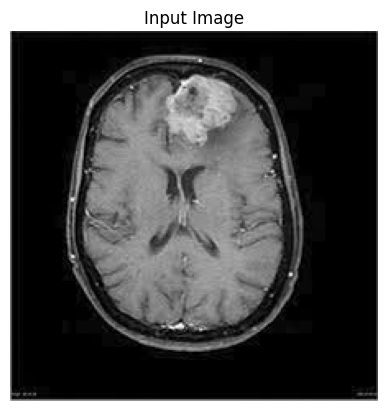

2026-03-31 11:41:54.046307: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 11:41:54.180252: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 11:41:54.479499: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 11:41:54.619579: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 11:41:55.369266: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
 Prediction: meningioma
 Confidence: 85.54%


In [202]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

# Load model
model = load_model("/kaggle/working/brain_tumor_final.keras")

# Classes (IMPORTANT: match training order)
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Load image (change path)
img_path = "/kaggle/input/datasets/harsh0812/test-image/images-2.jpeg"

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show image
plt.imshow(img_rgb)
plt.title("Input Image")
plt.axis("off")
plt.show()

# Resize
img_resized = cv2.resize(img_rgb, (300, 300))

# Preprocess
img_processed = preprocess_input(img_resized)

# Expand dims
img_input = np.expand_dims(img_processed, axis=0)

# Prediction
pred = model.predict(img_input)

class_idx = np.argmax(pred)
confidence = float(np.max(pred))
predicted_class = classes[class_idx]

#  SAFETY LOGIC
if confidence < 0.80:
    print(" Not a valid brain MRI / Uncertain image")
else:
    print(f" Prediction: {predicted_class}")
    print(f" Confidence: {confidence*100:.2f}%")

In [204]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [214]:
# Reset generator 
test_gen.reset()

# True labels
y_true = test_gen.classes

In [215]:
# Predict
y_pred_probs = model.predict(test_gen)

# Convert to class index
y_pred = np.argmax(y_pred_probs, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 142ms/step


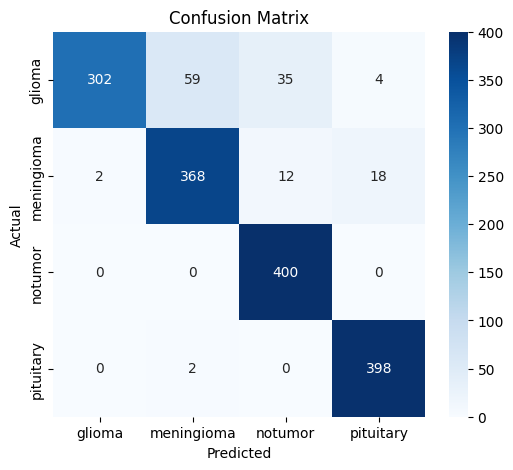

In [216]:
cm = confusion_matrix(y_true, y_pred)

classes = list(test_gen.class_indices.keys())

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [217]:
print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

      glioma       0.99      0.76      0.86       400
  meningioma       0.86      0.92      0.89       400
     notumor       0.89      1.00      0.94       400
   pituitary       0.95      0.99      0.97       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600

